In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import seaborn as sns
import json

# 한글 폰트 설정
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df_stores = pd.read_csv('서울시 상권분석서비스(점포-상권)_2024년.csv', encoding='utf-8')
df_sales = pd.read_csv('서울시 상권분석서비스(추정매출-상권)_2024년.csv', encoding='utf-8')

# JSON 파일 읽기
with open('서울시 상권분석서비스(영역-상권).json', encoding='utf-8') as f:
    area_json = json.load(f)

# JSON → 데이터프레임 변환
df_area = pd.DataFrame(area_json['DATA'])
df_area.rename(columns={'trdar_cd':'상권_코드', 'trdar_cd_nm':'상권_코드_명', 'relm_ar':'영역_면적'}, inplace=True)

# 타입 통일 (여기 추가해야 해!!)
df_stores['상권_코드'] = df_stores['상권_코드'].astype(str)
df_sales['상권_코드'] = df_sales['상권_코드'].astype(str)
df_area['상권_코드'] = df_area['상권_코드'].astype(str)

# 데이터 병합
df_merge = pd.merge(df_stores, df_sales, on=['상권_코드', '상권_코드_명', '상권_구분_코드', '상권_구분_코드_명', '서비스_업종_코드', '서비스_업종_코드_명'])
df_merge = pd.merge(df_merge, df_area[['상권_코드', '상권_코드_명', '영역_면적']], on=['상권_코드', '상권_코드_명'], how='left')

# 파생 변수 생성
df_merge['단위면적당_점포수'] = df_merge['점포_수'] / df_merge['영역_면적']
df_merge['단위면적당_매출액'] = df_merge['당월_매출_금액'] / df_merge['영역_면적']

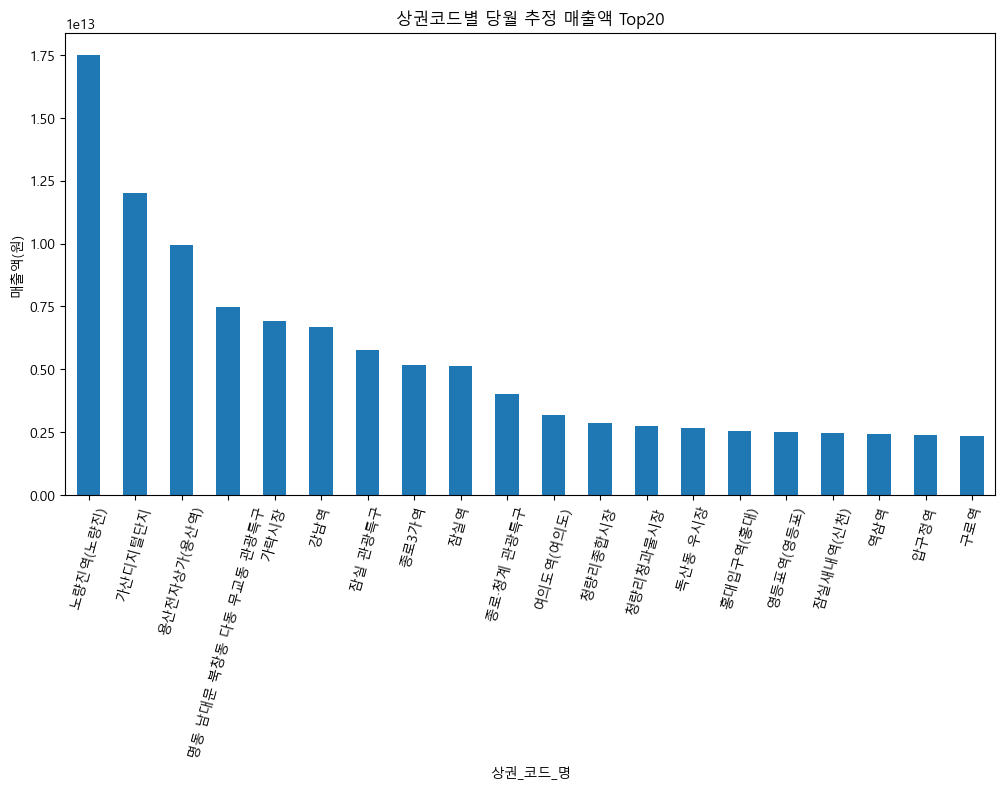

In [2]:
## 상권코드별 총 매출액
sales_by_area = df_merge.groupby('상권_코드_명')['당월_매출_금액'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sales_by_area.head(20).plot(kind='bar')
plt.title('상권코드별 당월 추정 매출액 Top20')
plt.ylabel('매출액(원)')
plt.xticks(rotation=75)
plt.show()

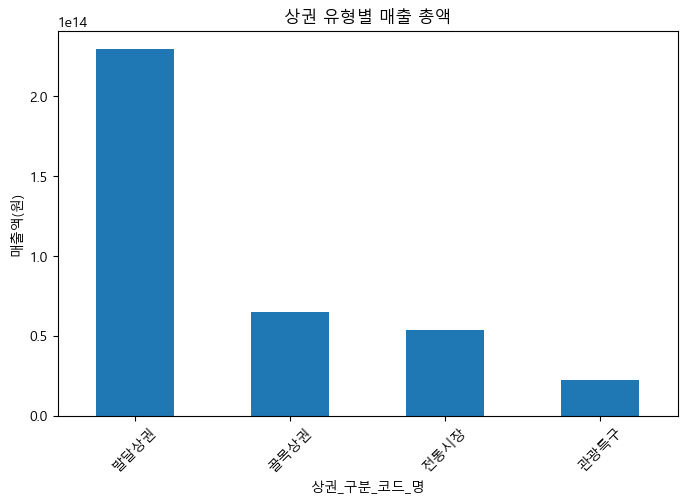

In [3]:
## 상권 유형별 매출
sales_by_type = df_merge.groupby('상권_구분_코드_명')['당월_매출_금액'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sales_by_type.plot(kind='bar')
plt.title('상권 유형별 매출 총액')
plt.ylabel('매출액(원)')
plt.xticks(rotation=45)
plt.show()

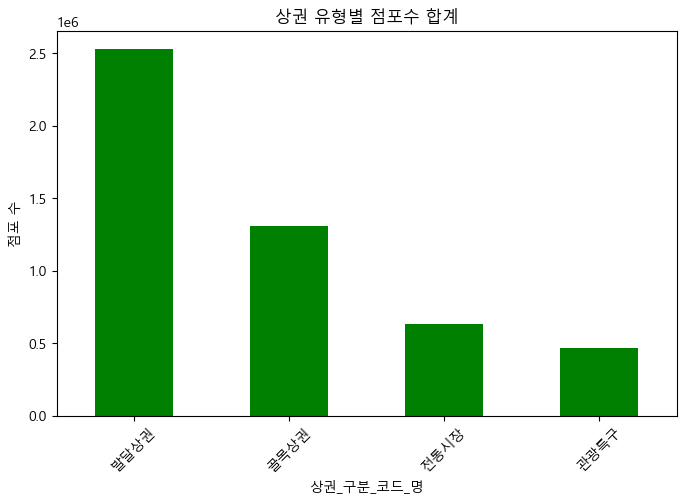

In [4]:
## 상권 유형별 점포수
stores_by_type = df_merge.groupby('상권_구분_코드_명')['점포_수'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
stores_by_type.plot(kind='bar', color='green')
plt.title('상권 유형별 점포수 합계')
plt.ylabel('점포 수')
plt.xticks(rotation=45)
plt.show()

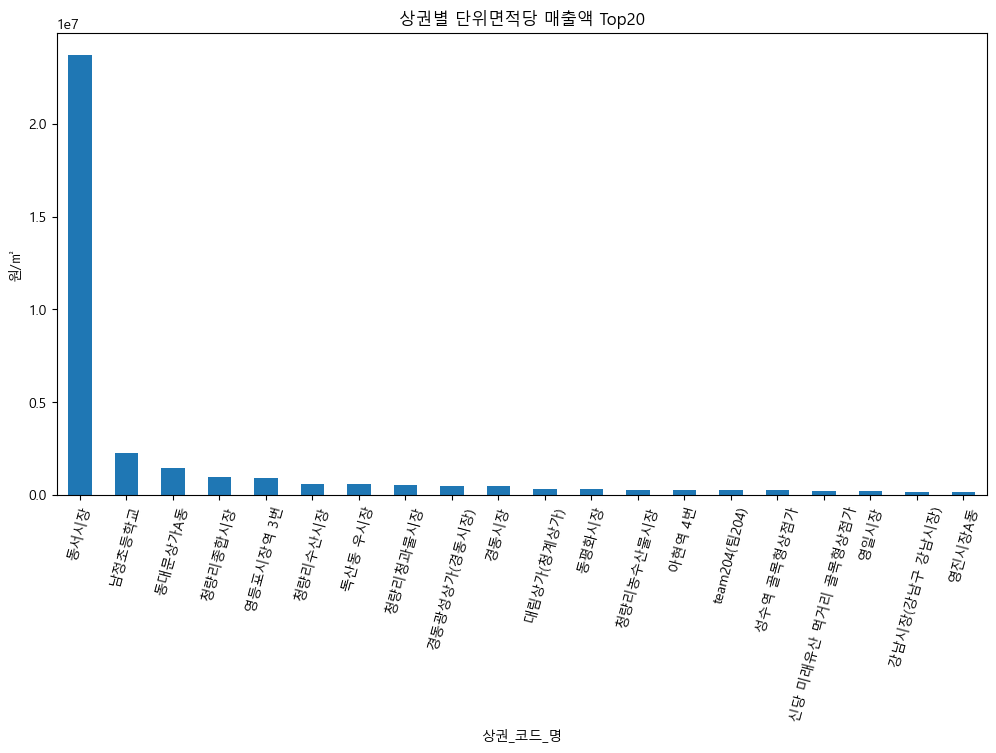

In [5]:
## 단위면적당 매출액 Top20
unit_sales = df_merge.groupby('상권_코드_명')['단위면적당_매출액'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
unit_sales.head(20).plot(kind='bar')
plt.title('상권별 단위면적당 매출액 Top20')
plt.ylabel('원/㎡')
plt.xticks(rotation=75)
plt.show()

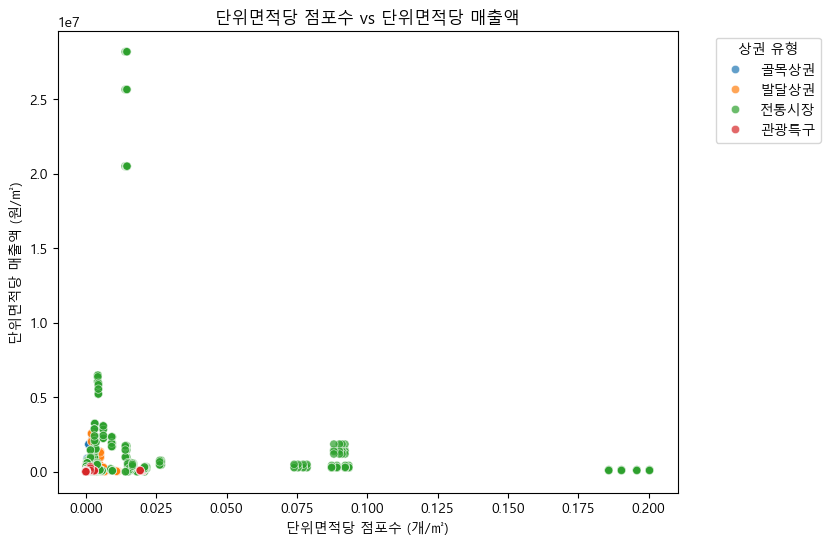

In [6]:
## 단위면적당 점포수 vs 단위면적당 매출액
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_merge, x='단위면적당_점포수', y='단위면적당_매출액', hue='상권_구분_코드_명', alpha=0.7)
plt.title('단위면적당 점포수 vs 단위면적당 매출액')
plt.xlabel('단위면적당 점포수 (개/㎡)')
plt.ylabel('단위면적당 매출액 (원/㎡)')
plt.legend(title='상권 유형', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

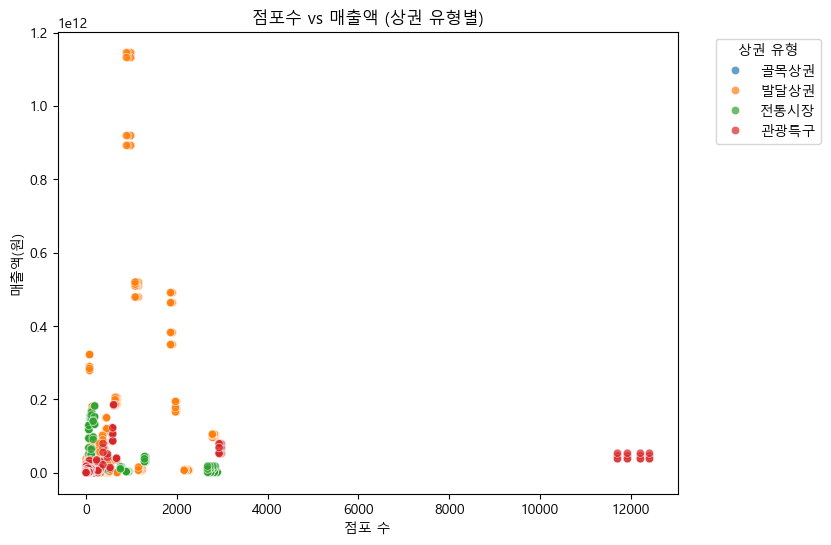

In [7]:
# 점포수 vs 매출액 관계
df_merge = pd.merge(df_stores, df_sales, on=['상권_코드', '상권_코드_명', '상권_구분_코드', '상권_구분_코드_명', '서비스_업종_코드', '서비스_업종_코드_명'])

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_merge, x='점포_수', y='당월_매출_금액', hue='상권_구분_코드_명', alpha=0.7)
plt.title('점포수 vs 매출액 (상권 유형별)')
plt.xlabel('점포 수')
plt.ylabel('매출액(원)')
plt.legend(title='상권 유형', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()